# Score Analysis: judge models and judge outputs

**Purpose:** Quantitative analysis of LLM judge scores (FUN, NSI, INSI, ISI) across all models. Shows which models performed scoring and how many comments each judged, computes detailed statistics and quantiles across all breakdowns, visualizes score distributions, and identifies all-zero score patterns.

**Scope:** Score statistics are grouped by repo, author_association, event type, user, and combinations thereof (up to 4-way breakdowns). Statistics include count, mean, median, and quantiles (p25, p50, p75, p99). **All models are included in the analysis** (combined).

**Reference:** Scoring rubric in [`papers/publication1/CONFORMITY_SYSTEM_PROMPT.md`](../papers/publication1/CONFORMITY_SYSTEM_PROMPT.md). Judge configuration and table structure in [`docs/DB_SCHEMA.md`](../docs/DB_SCHEMA.md).

In [1]:
import sys
from pathlib import Path

# Add repo root to sys.path so notebooks.lib can be imported
here = Path.cwd().resolve()
for p in [here, *here.parents]:
    if (p / "project_config.py").is_file():
        if str(p) not in sys.path:
            sys.path.insert(0, str(p))
        break

In [2]:
import json
from html import escape

import pandas as pd
from IPython.display import HTML, Markdown, display

from notebooks.lib import (
    connect,
    DB_PATH,
    load_scores_with_metadata,
    all_zero_scores_mask,
    score_stats_by_repo,
    score_stats_by_repo_author_association,
    score_stats_by_repo_event_type,
    score_stats_by_repo_aa_user,
    score_stats_by_repo_aa_user_event_type,
    total_score_by_repo_table,
    plot_global_score_histograms_all_vs_non_full_zero,
    plot_score_summaries_by_category,
    plot_total_score_by_repo,
    display_dataframe_scrollable,
    display_all_zero_score_comment_samples,
)

pd.set_option("display.max_rows", 20)
pd.set_option("display.max_colwidth", None)

print(f"DB: {DB_PATH.resolve()}  exists={DB_PATH.is_file()}")

DB: /Users/naataaniitsosie/repos/swe-principals/data/raw/events.db  exists=True


## Judge Models and Coverage

Which models scored comments, and how many scores did each model produce?

In [3]:
with connect() as conn:
    models_df = pd.read_sql(
        """
        SELECT
            experiment_version,
            model_name,
            COUNT(*) AS n_total,
            SUM(CASE WHEN parse_ok = 1 THEN 1 ELSE 0 END) AS n_scores,
            SUM(CASE WHEN parse_ok = 0 THEN 1 ELSE 0 END) AS n_failures
        FROM scores
        GROUP BY experiment_version, model_name
        ORDER BY experiment_version, n_total DESC
        """,
        conn
    )

display(Markdown("**Score rows per judge model:**"))
display(models_df)

with connect() as conn:
    total_sampled = int(pd.read_sql("SELECT COUNT(*) FROM samples", conn)["COUNT(*)"].iloc[0])

display(Markdown(f"\n**Context:** {total_sampled:,} comments in the stratified sample. Each model above scored this corpus."))

**Score rows per judge model:**

,experiment_version,model_name,n_total,n_scores,n_failures
0,1,openai/gpt-5.4-mini,1903,1902,1
1,1,google/gemini-2.5-flash,1903,1883,20
2,1,anthropic/claude-haiku-4-5,1903,1894,9
3,1,gemma4:26b,100,55,45



**Context:** 1,903 comments in the stratified sample. Each model above scored this corpus.

## Conformity Score Distribution by Model

`ConformityScore = nsi_score + insi_score + isi_score` (range 0–9), computed in memory. Rows with ConformityScore = 0 are excluded. One histogram per judge model.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

FRONTIER_MODELS = [
    "openai/gpt-5.4-mini",
    "google/gemini-2.5-flash",
    "anthropic/claude-haiku-4-5",
]

df_cs = load_scores_with_metadata(model_allowlist=FRONTIER_MODELS).copy()
for c in ["nsi_score", "insi_score", "isi_score"]:
    df_cs[c] = pd.to_numeric(df_cs[c], errors="coerce").fillna(0).astype(int)

df_cs["conformity_score"] = df_cs["nsi_score"] + df_cs["insi_score"] + df_cs["isi_score"]

models = sorted(df_cs["model_name"].unique())
bins = np.arange(0, 11) - 0.5  # bins centered on integers 0–9

fig, axes = plt.subplots(1, len(models), figsize=(3.5 * len(models), 2.5), sharey=False)
if len(models) == 1:
    axes = [axes]

for ax, model in zip(axes, models):
    scores = df_cs.loc[df_cs["model_name"] == model, "conformity_score"]
    ax.hist(scores, bins=bins, color="#4c72b0", edgecolor="white", rwidth=0.85)
    ax.set_title(model, fontsize=8)
    ax.set_xticks(range(0, 10))
    ax.set_xlim(-0.5, 9.5)
    ax.tick_params(axis="both", labelsize=7)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.18)
    for xi in range(0, 10):
        n = int((scores == xi).sum())
        if n > 0:
            ax.text(xi, n, str(n), ha="center", va="bottom", fontsize=6)

plt.tight_layout()
plt.show()

print(f"\nTotal parsed rows: {len(df_cs):,}")

## Filter by Model

Select which model(s) to analyze. All statistics below will be computed for the selected model(s) only.

In [23]:
from ipywidgets import SelectMultiple, Output, VBox, Label
import ipywidgets as widgets

# Get list of available models
with connect() as conn:
    available_models = pd.read_sql(
        "SELECT DISTINCT model_name FROM scores ORDER BY model_name",
        conn
    )["model_name"].tolist()

# Create widget for model selection
model_selector = SelectMultiple(
    options=available_models,
    value=tuple(available_models),  # Select all by default
    description="Models:",
    disabled=False,
    rows=len(available_models) if len(available_models) <= 5 else 5
)

display(Label("Select one or more models (or leave empty for all):"))
display(model_selector)

# Store selected models for use in subsequent cells
SELECTED_MODELS = None

def update_selected_models(*args):
    global SELECTED_MODELS
    SELECTED_MODELS = list(model_selector.value) if model_selector.value else available_models

model_selector.observe(update_selected_models, names='value')
update_selected_models()  # Initialize

display(Markdown(f"**Selected models:** {', '.join(SELECTED_MODELS) if SELECTED_MODELS else 'All'}"))

Label(value='Select one or more models (or leave empty for all):')

SelectMultiple(description='Models:', index=(0, 1, 2, 3), options=('anthropic/claude-haiku-4-5', 'gemma4:26b',…

**Selected models:** anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini

## Score Statistics and Distributions

Loads scores with event metadata (repo, author_association, user_login, event_type). Statistics include count, mean, median, and quantiles per group. Optional filtering for all-zero score rows.

In [24]:
# Helper function to filter scores by selected models
def filter_by_selected_models(df):
    """Filter dataframe to only include selected models."""
    if SELECTED_MODELS:
        return df[df['model_name'].isin(SELECTED_MODELS)]
    return df

def add_model_column(df, filtered_df):
    """Add model column at the beginning showing which model(s) were included."""
    if len(SELECTED_MODELS) == 1:
        df.insert(0, 'model_name', SELECTED_MODELS[0])
    else:
        # For multi-model, show which models were combined
        models_str = ', '.join(sorted(SELECTED_MODELS))
        df.insert(0, 'models', models_str)
    return df

# Load scores data filtered by selected models
df_filtered = filter_by_selected_models(load_scores_with_metadata())

display(Markdown(f"**Analyzing {len(df_filtered):,} scores** from model(s): {', '.join(SELECTED_MODELS)}"))

**Analyzing 5,734 scores** from model(s): anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini

### By Repo

In [25]:
display(Markdown("**Score stats by repo**"))
stats_by_repo = score_stats_by_repo(df_filtered)
stats_by_repo = add_model_column(stats_by_repo, df_filtered)
display(stats_by_repo)

display(Markdown("**Total score (FUN+NSI+INSI+ISI) by repo** — per-row totals range 0–12"))
total_by_repo = total_score_by_repo_table(df_filtered)
total_by_repo = add_model_column(total_by_repo, df_filtered)
display(total_by_repo)

**Score stats by repo**

,models,repo,n_rows,fun_score_n,fun_score_avg,fun_score_mean,fun_score_median,fun_score_p25,fun_score_p50,fun_score_p75,...,insi_score_p75,insi_score_p99,isi_score_n,isi_score_avg,isi_score_mean,isi_score_median,isi_score_p25,isi_score_p50,isi_score_p75,isi_score_p99
0,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",django/django,655,655,0.743511,0.743511,0.0,0.0,0.0,2.0,...,0.0,2.0,655,0.760305,0.760305,0.0,0.0,0.0,1.0,3.0
1,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",expressjs/express,597,597,0.559464,0.559464,0.0,0.0,0.0,1.0,...,0.0,2.0,597,0.705193,0.705193,0.0,0.0,0.0,1.0,3.0
2,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",fastify/fastify,600,600,0.828333,0.828333,0.0,0.0,0.0,2.0,...,0.0,2.0,600,0.763333,0.763333,0.0,0.0,0.0,2.0,3.0
3,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",gin-gonic/gin,599,599,1.003339,1.003339,1.0,0.0,1.0,2.0,...,0.0,2.0,599,0.998331,0.998331,1.0,0.0,1.0,2.0,3.0
4,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",hapijs/hapi,531,531,1.252354,1.252354,1.0,0.0,1.0,2.0,...,0.0,2.0,531,1.167608,1.167608,1.0,0.0,1.0,2.0,3.0
5,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",koajs/koa,493,493,0.951318,0.951318,0.0,0.0,0.0,2.0,...,0.0,2.0,493,0.918864,0.918864,1.0,0.0,1.0,2.0,3.0
6,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",nestjs/nest,599,599,0.717863,0.717863,0.0,0.0,0.0,1.0,...,0.0,2.0,599,0.901503,0.901503,1.0,0.0,1.0,2.0,3.0
7,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",pallets/flask,475,475,0.928421,0.928421,0.0,0.0,0.0,2.0,...,0.0,2.0,475,0.945263,0.945263,1.0,0.0,1.0,2.0,3.0
8,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",spring-projects/spring-boot,595,595,0.757983,0.757983,0.0,0.0,0.0,1.0,...,0.0,2.0,595,0.984874,0.984874,1.0,0.0,1.0,2.0,3.0
9,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",tiangolo/fastapi,590,590,0.400000,0.400000,0.0,0.0,0.0,0.0,...,0.0,2.0,590,0.564407,0.564407,0.0,0.0,0.0,1.0,3.0


**Total score (FUN+NSI+INSI+ISI) by repo** — per-row totals range 0–12

,models,repo,n_rows,sum_total_score,mean_total_score,median_total_score,std_total_score
0,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",django/django,655,1294,1.975573,2.0,1.834768
1,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",expressjs/express,597,1139,1.907873,2.0,1.917743
2,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",fastify/fastify,600,1288,2.146667,2.0,1.907324
3,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",gin-gonic/gin,599,1392,2.323873,2.0,1.723907
4,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",hapijs/hapi,531,1485,2.796610,3.0,1.977245
5,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",koajs/koa,493,1097,2.225152,2.0,1.772651
6,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",nestjs/nest,599,1179,1.968280,2.0,1.803192
7,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",pallets/flask,475,1168,2.458947,3.0,1.836083
8,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",spring-projects/spring-boot,595,1341,2.253782,2.0,1.830659
9,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",tiangolo/fastapi,590,781,1.323729,1.0,1.572886


### By Repo × Author Association

In [26]:
display(Markdown("**Score stats by repo × author_association**"))
stats = score_stats_by_repo_author_association(df_filtered)
stats = add_model_column(stats, df_filtered)
display_dataframe_scrollable(stats)

**Score stats by repo × author_association**

,models,repo,author_association,n_rows,fun_score_n,fun_score_avg,fun_score_mean,fun_score_median,fun_score_p25,fun_score_p50,fun_score_p75,fun_score_p99,nsi_score_n,nsi_score_avg,nsi_score_mean,nsi_score_median,nsi_score_p25,nsi_score_p50,nsi_score_p75,nsi_score_p99,insi_score_n,insi_score_avg,insi_score_mean,insi_score_median,insi_score_p25,insi_score_p50,insi_score_p75,insi_score_p99,isi_score_n,isi_score_avg,isi_score_mean,isi_score_median,isi_score_p25,isi_score_p50,isi_score_p75,isi_score_p99
0,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",django/django,(empty),13,13,0.384615,0.384615,0.0,0.0,0.0,0.00,2.76,13,0.153846,0.153846,0.0,0.0,0.0,0.0,1.76,13,0.307692,0.307692,0.0,0.0,0.0,0.0,2.76,13,0.538462,0.538462,0.0,0.0,0.0,1.00,1.88
1,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",django/django,CONTRIBUTOR,315,315,0.663492,0.663492,0.0,0.0,0.0,1.00,3.00,315,0.307937,0.307937,0.0,0.0,0.0,0.0,3.00,315,0.203175,0.203175,0.0,0.0,0.0,0.0,2.00,315,0.711111,0.711111,0.0,0.0,0.0,1.00,3.00
2,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",django/django,MEMBER,230,230,0.708696,0.708696,0.0,0.0,0.0,1.00,3.00,230,0.286957,0.286957,0.0,0.0,0.0,0.0,3.00,230,0.230435,0.230435,0.0,0.0,0.0,0.0,2.00,230,0.821739,0.821739,0.0,0.0,0.0,2.00,3.00
3,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",django/django,NONE,97,97,1.134021,1.134021,1.0,0.0,1.0,2.00,3.00,97,0.144330,0.144330,0.0,0.0,0.0,0.0,2.04,97,0.092784,0.092784,0.0,0.0,0.0,0.0,2.00,97,0.804124,0.804124,1.0,0.0,1.0,2.00,3.00
4,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",expressjs/express,(empty),15,15,0.200000,0.200000,0.0,0.0,0.0,0.00,1.00,15,0.133333,0.133333,0.0,0.0,0.0,0.0,1.00,15,0.200000,0.200000,0.0,0.0,0.0,0.0,1.00,15,0.533333,0.533333,0.0,0.0,0.0,1.00,2.00
5,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",expressjs/express,CONTRIBUTOR,60,60,0.850000,0.850000,0.0,0.0,0.0,2.00,3.00,60,0.183333,0.183333,0.0,0.0,0.0,0.0,2.00,60,0.366667,0.366667,0.0,0.0,0.0,0.0,2.41,60,1.000000,1.000000,1.0,0.0,1.0,2.00,3.00
6,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",expressjs/express,MEMBER,282,282,0.514184,0.514184,0.0,0.0,0.0,1.00,3.00,282,0.503546,0.503546,0.0,0.0,0.0,0.0,3.00,282,0.290780,0.290780,0.0,0.0,0.0,0.0,2.00,282,0.680851,0.680851,0.0,0.0,0.0,1.00,3.00
7,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",expressjs/express,NONE,240,240,0.562500,0.562500,0.0,0.0,0.0,1.00,3.00,240,0.337500,0.337500,0.0,0.0,0.0,0.0,3.00,240,0.170833,0.170833,0.0,0.0,0.0,0.0,2.00,240,0.670833,0.670833,0.0,0.0,0.0,1.00,3.00
8,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",fastify/fastify,(empty),6,6,0.166667,0.166667,0.0,0.0,0.0,0.00,0.95,6,0.000000,0.000000,0.0,0.0,0.0,0.0,0.00,6,0.666667,0.666667,0.0,0.0,0.0,1.5,2.00,6,1.000000,1.000000,1.0,0.0,1.0,2.00,2.00
9,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",fastify/fastify,CONTRIBUTOR,147,147,0.721088,0.721088,0.0,0.0,0.0,1.00,3.00,147,0.306122,0.306122,0.0,0.0,0.0,0.0,3.00,147,0.292517,0.292517,0.0,0.0,0.0,0.0,3.00,147,0.755102,0.755102,0.0,0.0,0.0,1.50,3.00


### By Repo × Event Type

In [27]:
display(Markdown("**Score stats by repo × event type** — top-level `$.type` from `events.event_data`"))
pd.set_option("display.max_rows", 500)
stats = score_stats_by_repo_event_type(df_filtered)
stats = add_model_column(stats, df_filtered)
display_dataframe_scrollable(stats)
pd.set_option("display.max_rows", 20)

**Score stats by repo × event type** — top-level `$.type` from `events.event_data`

,models,repo,event_type,n_rows,fun_score_n,fun_score_avg,fun_score_mean,fun_score_median,fun_score_p25,fun_score_p50,fun_score_p75,fun_score_p99,nsi_score_n,nsi_score_avg,nsi_score_mean,nsi_score_median,nsi_score_p25,nsi_score_p50,nsi_score_p75,nsi_score_p99,insi_score_n,insi_score_avg,insi_score_mean,insi_score_median,insi_score_p25,insi_score_p50,insi_score_p75,insi_score_p99,isi_score_n,isi_score_avg,isi_score_mean,isi_score_median,isi_score_p25,isi_score_p50,isi_score_p75,isi_score_p99
0,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",django/django,IssueCommentEvent,177,177,0.519774,0.519774,0.0,0.00,0.0,1.0,3.00,177,0.231638,0.231638,0.0,0.0,0.0,0.0,3.00,177,0.152542,0.152542,0.0,0.0,0.0,0.00,2.00,177,0.672316,0.672316,0.0,0.0,0.0,1.0,3.00
1,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",django/django,PullRequestEvent,178,178,1.567416,1.567416,2.0,0.00,2.0,3.0,3.00,178,0.247191,0.247191,0.0,0.0,0.0,0.0,3.00,178,0.033708,0.033708,0.0,0.0,0.0,0.00,1.00,178,0.904494,0.904494,1.0,0.0,1.0,2.0,3.00
2,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",django/django,PullRequestReviewCommentEvent,150,150,0.606667,0.606667,0.0,0.00,0.0,1.0,3.00,150,0.313333,0.313333,0.0,0.0,0.0,0.0,2.51,150,0.466667,0.466667,0.0,0.0,0.0,1.00,2.51,150,1.020000,1.020000,1.0,0.0,1.0,2.0,3.00
3,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",django/django,PullRequestReviewEvent,150,150,0.166667,0.166667,0.0,0.00,0.0,0.0,3.00,150,0.313333,0.313333,0.0,0.0,0.0,0.0,2.51,150,0.180000,0.180000,0.0,0.0,0.0,0.00,2.00,150,0.433333,0.433333,0.0,0.0,0.0,1.0,2.00
4,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",expressjs/express,IssueCommentEvent,150,150,0.720000,0.720000,0.0,0.00,0.0,1.0,3.00,150,0.366667,0.366667,0.0,0.0,0.0,0.0,3.00,150,0.240000,0.240000,0.0,0.0,0.0,0.00,2.51,150,0.980000,0.980000,0.5,0.0,0.5,2.0,3.00
5,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",expressjs/express,PullRequestEvent,148,148,0.506757,0.506757,0.0,0.00,0.0,1.0,3.00,148,0.527027,0.527027,0.0,0.0,0.0,0.0,3.00,148,0.168919,0.168919,0.0,0.0,0.0,0.00,2.00,148,0.594595,0.594595,0.0,0.0,0.0,1.0,3.00
6,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",expressjs/express,PullRequestReviewCommentEvent,150,150,0.680000,0.680000,0.0,0.00,0.0,1.0,3.00,150,0.346667,0.346667,0.0,0.0,0.0,0.0,3.00,150,0.253333,0.253333,0.0,0.0,0.0,0.00,2.00,150,0.840000,0.840000,0.0,0.0,0.0,2.0,3.00
7,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",expressjs/express,PullRequestReviewEvent,149,149,0.328859,0.328859,0.0,0.00,0.0,0.0,2.00,149,0.342282,0.342282,0.0,0.0,0.0,0.0,3.00,149,0.328859,0.328859,0.0,0.0,0.0,0.00,3.00,149,0.402685,0.402685,0.0,0.0,0.0,1.0,2.00
8,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",fastify/fastify,IssueCommentEvent,150,150,0.780000,0.780000,0.0,0.00,0.0,2.0,3.00,150,0.166667,0.166667,0.0,0.0,0.0,0.0,2.51,150,0.240000,0.240000,0.0,0.0,0.0,0.00,2.00,150,0.700000,0.700000,0.0,0.0,0.0,1.0,3.00
9,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",fastify/fastify,PullRequestEvent,150,150,1.326667,1.326667,1.0,0.00,1.0,3.0,3.00,150,0.560000,0.560000,0.0,0.0,0.0,1.0,3.00,150,0.086667,0.086667,0.0,0.0,0.0,0.00,1.51,150,0.886667,0.886667,1.0,0.0,1.0,2.0,3.00


### By Repo × Author Association × User Login

In [28]:
display(Markdown(
    "**Score stats by repo × author_association × user_login**\n\n"
    "User login: `payload.comment.user.login` / `review.user.login`, else `actor.login`"
))
pd.set_option("display.max_rows", 500)
stats = score_stats_by_repo_aa_user(df_filtered)
stats = add_model_column(stats, df_filtered)
display_dataframe_scrollable(stats)
pd.set_option("display.max_rows", 20)

**Score stats by repo × author_association × user_login**

User login: `payload.comment.user.login` / `review.user.login`, else `actor.login`

,models,repo,author_association,user_login,n_rows,fun_score_n,fun_score_avg,fun_score_mean,fun_score_median,fun_score_p25,fun_score_p50,fun_score_p75,fun_score_p99,nsi_score_n,nsi_score_avg,nsi_score_mean,nsi_score_median,nsi_score_p25,nsi_score_p50,nsi_score_p75,nsi_score_p99,insi_score_n,insi_score_avg,insi_score_mean,insi_score_median,insi_score_p25,insi_score_p50,insi_score_p75,insi_score_p99,isi_score_n,isi_score_avg,isi_score_mean,isi_score_median,isi_score_p25,isi_score_p50,isi_score_p75,isi_score_p99
0,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",django/django,(empty),casey-brooks,4,4,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,4,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,4,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,4,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00
1,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",django/django,(empty),cliffordgama,3,3,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,3,0.666667,0.666667,0.0,0.00,0.0,1.00,1.96,3,1.333333,1.333333,1.0,0.50,1.0,2.00,2.96,3,0.333333,0.333333,0.0,0.00,0.0,0.50,0.98
2,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",django/django,(empty),jacobtylerwalls,3,3,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,3,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,3,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,3,1.000000,1.000000,1.0,1.00,1.0,1.00,1.00
3,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",django/django,(empty),p-r-a-v-i-n,3,3,1.666667,1.666667,1.0,1.00,1.0,2.00,2.96,3,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,3,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,3,1.000000,1.000000,1.0,0.50,1.0,1.50,1.98
4,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",django/django,CONTRIBUTOR,Akash-Kumar-Sen,3,3,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,3,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,3,0.666667,0.666667,0.0,0.00,0.0,1.00,1.96,3,0.333333,0.333333,0.0,0.00,0.0,0.50,0.98
5,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",django/django,CONTRIBUTOR,Bakdolot,3,3,2.333333,2.333333,2.0,2.00,2.0,2.50,2.98,3,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,3,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,3,1.000000,1.000000,1.0,1.00,1.0,1.00,1.00
6,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",django/django,CONTRIBUTOR,DevilsAutumn,4,4,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,4,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,4,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,4,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00
7,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",django/django,CONTRIBUTOR,JaeHyuckSa,6,6,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,6,1.000000,1.000000,1.0,0.25,1.0,1.75,2.00,6,1.000000,1.000000,1.0,0.00,1.0,2.00,2.00,6,0.166667,0.166667,0.0,0.00,0.0,0.00,0.95
8,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",django/django,CONTRIBUTOR,LilyFoote,6,6,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,6,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,6,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,6,0.166667,0.166667,0.0,0.00,0.0,0.00,0.95
9,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",django/django,CONTRIBUTOR,UnknownPlatypus,3,3,1.666667,1.666667,2.0,1.50,2.0,2.00,2.00,3,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,3,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,3,2.666667,2.666667,3.0,2.50,3.0,3.00,3.00


### By Repo × Author Association × User Login × Event Type

In [29]:
display(Markdown(
    "**Score stats by repo × author_association × user_login × event type** — 4-way breakdown"
))
pd.set_option("display.max_rows", 800)
stats = score_stats_by_repo_aa_user_event_type(df_filtered)
stats = add_model_column(stats, df_filtered)
display_dataframe_scrollable(stats, max_height="36rem")
pd.set_option("display.max_rows", 20)

**Score stats by repo × author_association × user_login × event type** — 4-way breakdown

,models,repo,author_association,user_login,event_type,n_rows,fun_score_n,fun_score_avg,fun_score_mean,fun_score_median,fun_score_p25,fun_score_p50,fun_score_p75,fun_score_p99,nsi_score_n,nsi_score_avg,nsi_score_mean,nsi_score_median,nsi_score_p25,nsi_score_p50,nsi_score_p75,nsi_score_p99,insi_score_n,insi_score_avg,insi_score_mean,insi_score_median,insi_score_p25,insi_score_p50,insi_score_p75,insi_score_p99,isi_score_n,isi_score_avg,isi_score_mean,isi_score_median,isi_score_p25,isi_score_p50,isi_score_p75,isi_score_p99
0,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",django/django,(empty),casey-brooks,IssueCommentEvent,4,4,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,4,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,4,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,4,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00
1,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",django/django,(empty),cliffordgama,PullRequestReviewCommentEvent,3,3,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,3,0.666667,0.666667,0.0,0.00,0.0,1.00,1.96,3,1.333333,1.333333,1.0,0.50,1.0,2.00,2.96,3,0.333333,0.333333,0.0,0.00,0.0,0.50,0.98
2,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",django/django,(empty),jacobtylerwalls,PullRequestReviewCommentEvent,3,3,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,3,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,3,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,3,1.000000,1.000000,1.0,1.00,1.0,1.00,1.00
3,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",django/django,(empty),p-r-a-v-i-n,IssueCommentEvent,3,3,1.666667,1.666667,1.0,1.00,1.0,2.00,2.96,3,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,3,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,3,1.000000,1.000000,1.0,0.50,1.0,1.50,1.98
4,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",django/django,CONTRIBUTOR,Akash-Kumar-Sen,PullRequestReviewCommentEvent,3,3,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,3,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,3,0.666667,0.666667,0.0,0.00,0.0,1.00,1.96,3,0.333333,0.333333,0.0,0.00,0.0,0.50,0.98
5,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",django/django,CONTRIBUTOR,Bakdolot,PullRequestEvent,3,3,2.333333,2.333333,2.0,2.00,2.0,2.50,2.98,3,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,3,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,3,1.000000,1.000000,1.0,1.00,1.0,1.00,1.00
6,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",django/django,CONTRIBUTOR,DevilsAutumn,IssueCommentEvent,4,4,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,4,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,4,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,4,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00
7,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",django/django,CONTRIBUTOR,JaeHyuckSa,IssueCommentEvent,6,6,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,6,1.000000,1.000000,1.0,0.25,1.0,1.75,2.00,6,1.000000,1.000000,1.0,0.00,1.0,2.00,2.00,6,0.166667,0.166667,0.0,0.00,0.0,0.00,0.95
8,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",django/django,CONTRIBUTOR,LilyFoote,PullRequestReviewEvent,6,6,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,6,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,6,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,6,0.166667,0.166667,0.0,0.00,0.0,0.00,0.95
9,"anthropic/claude-haiku-4-5, gemma4:26b, google/gemini-2.5-flash, openai/gpt-5.4-mini",django/django,CONTRIBUTOR,UnknownPlatypus,PullRequestReviewCommentEvent,3,3,1.666667,1.666667,2.0,1.50,2.0,2.00,2.00,3,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,3,0.000000,0.000000,0.0,0.00,0.0,0.00,0.00,3,2.666667,2.666667,3.0,2.50,3.0,3.00,3.00


## Visualizations: Score Distributions

### Global Marginal Histograms

Counts at ordinal scores 0, 1, 2, 3 for each of FUN, NSI, INSI, ISI. Two figures: full cohort vs after removing all-zero rows.

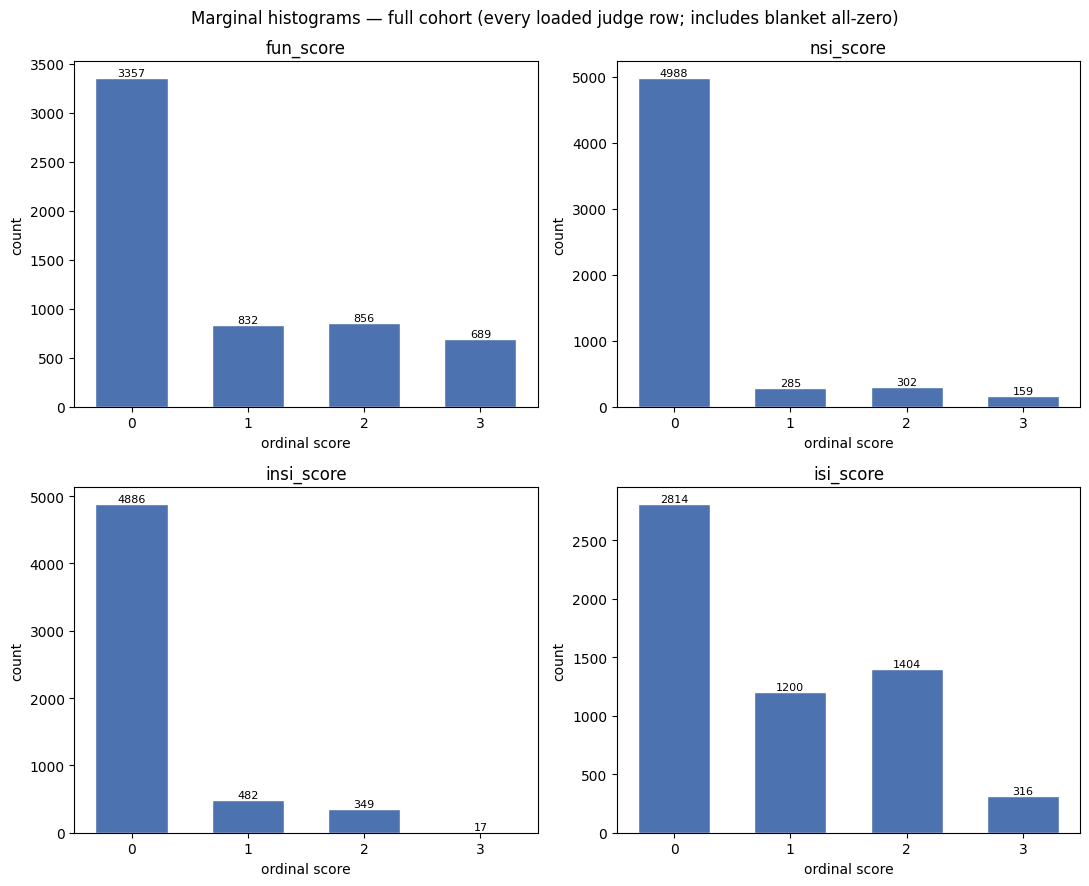

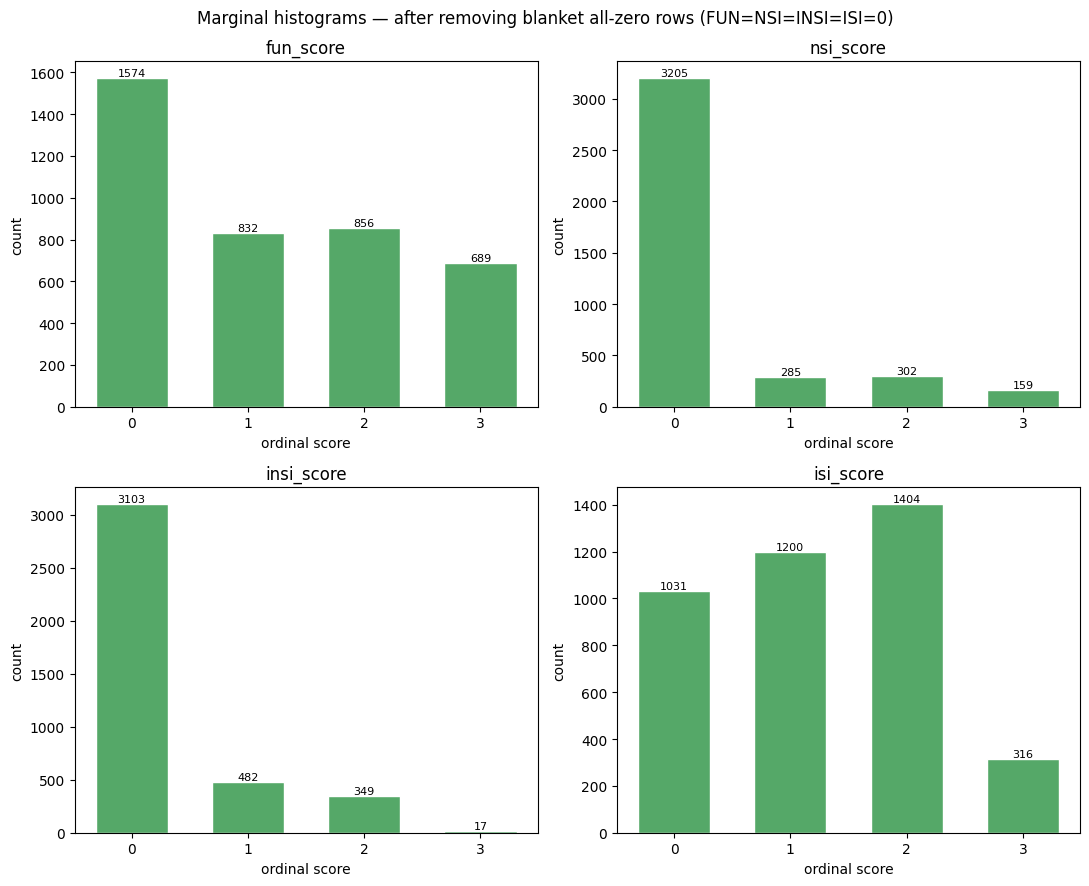

In [30]:
df_plot = df_filtered.copy()
for c in ["fun_score", "nsi_score", "insi_score", "isi_score"]:
    df_plot[c] = pd.to_numeric(df_plot[c], errors="coerce").fillna(0).astype(int)

model_label = f" (model: {SELECTED_MODELS[0]})" if len(SELECTED_MODELS) == 1 else f" (models: {', '.join(SELECTED_MODELS)})"
plot_global_score_histograms_all_vs_non_full_zero(df_plot, compare_full_population=True, single_figure_title=f"Score distributions{model_label}")

### By Repo

Stacked counts at ordinal 0/1/2/3 per repo (full-zero judge rows excluded).

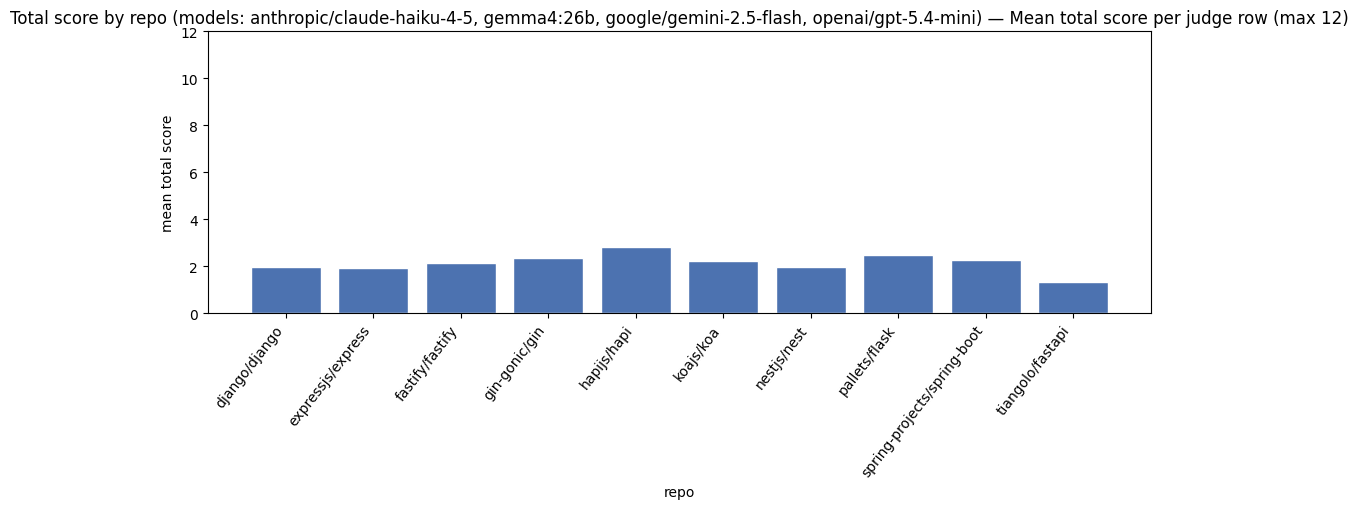

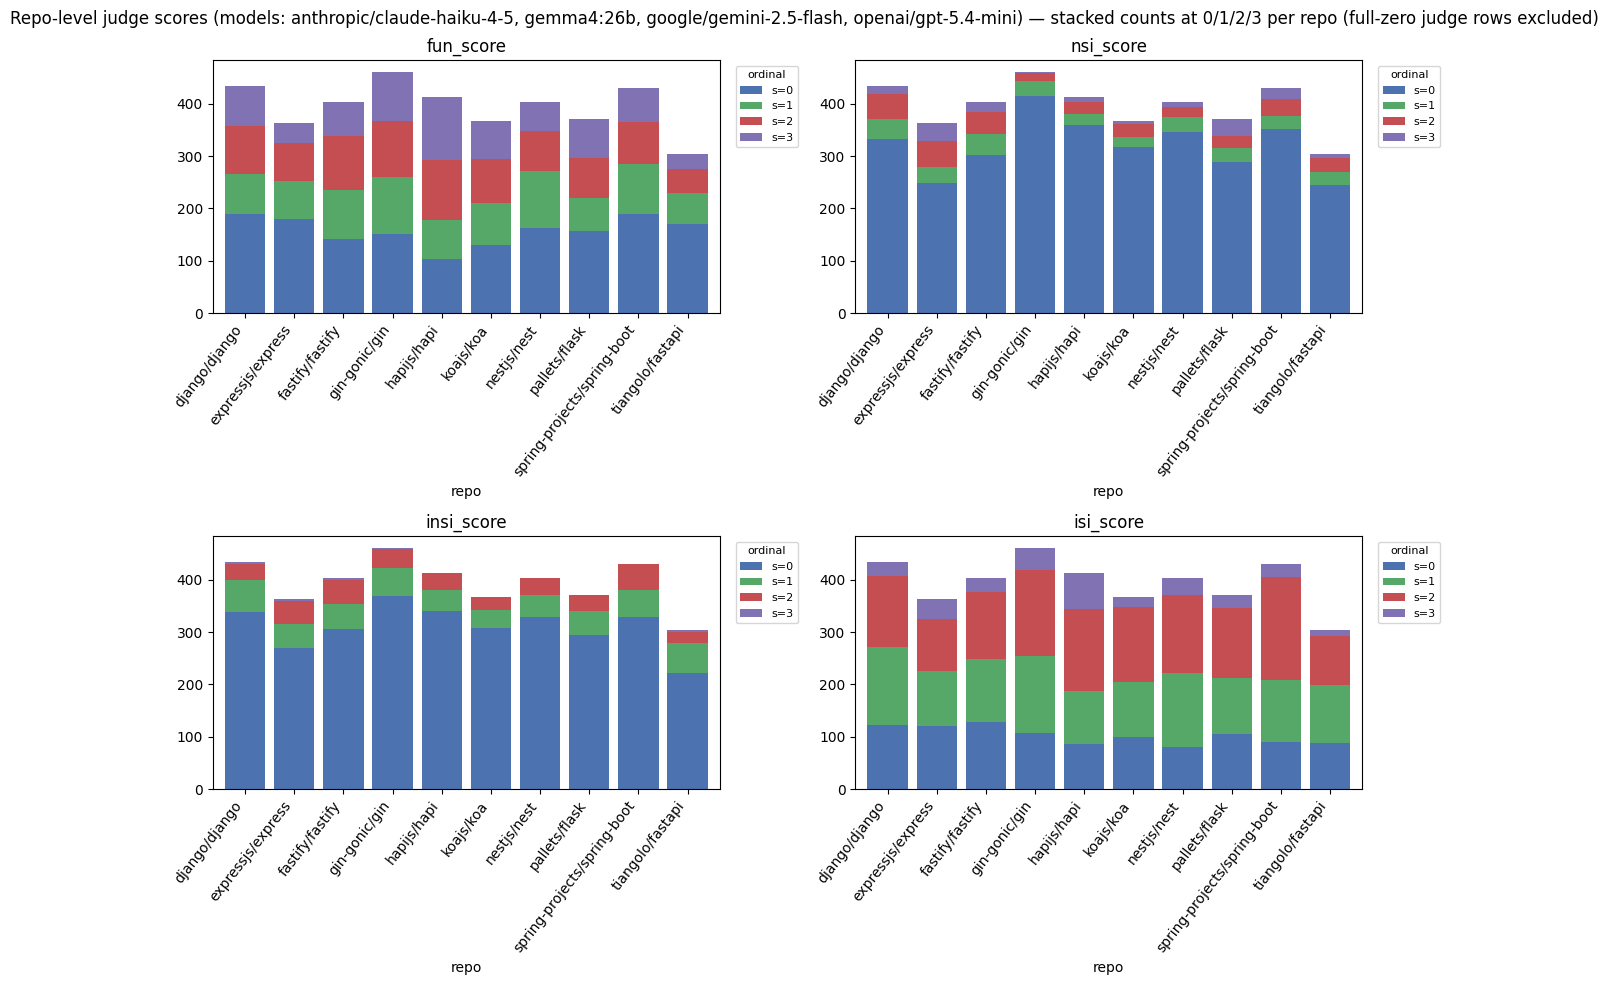

In [31]:
model_label = f" (model: {SELECTED_MODELS[0]})" if len(SELECTED_MODELS) == 1 else f" (models: {', '.join(SELECTED_MODELS)})"
plot_total_score_by_repo(df_plot, title_prefix=f"Total score by repo{model_label}")
plot_score_summaries_by_category(
    df_plot,
    category_col="repo",
    title=f"Repo-level judge scores{model_label}"
)

### By Event Type

Stacked counts per event type (top-level `$.type`). Four separate figures per score dimension for independent saving. Horizontal bars with tight margins on y-axis. Full-zero judge rows excluded.

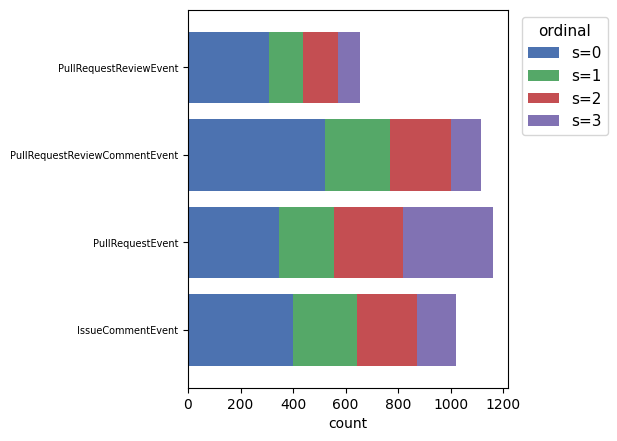

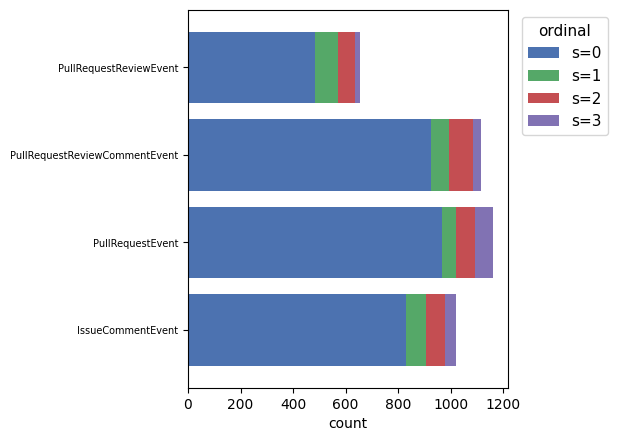

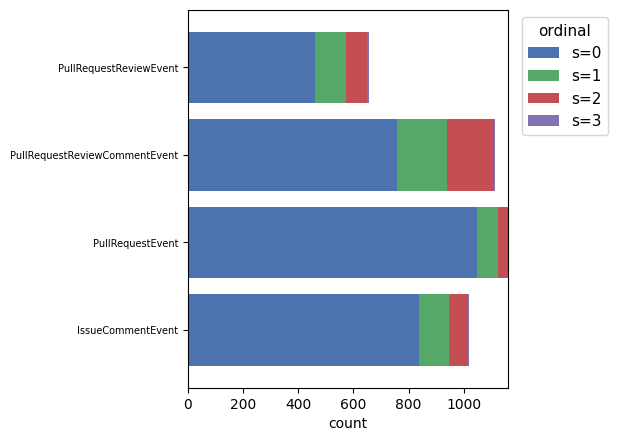

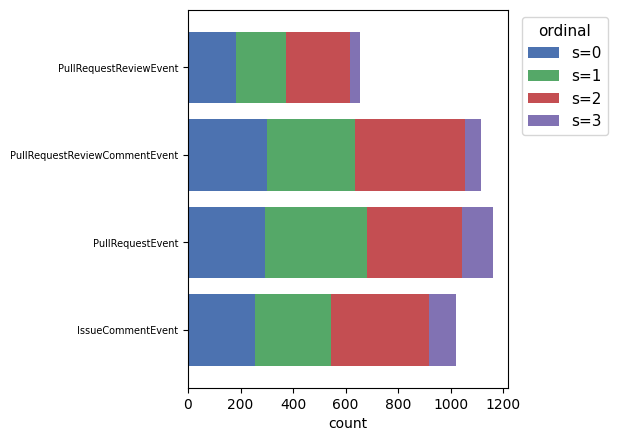

In [32]:
model_label = f" (model: {SELECTED_MODELS[0]})" if len(SELECTED_MODELS) == 1 else f" (models: {', '.join(SELECTED_MODELS)})"
plot_score_summaries_by_category(
    df_plot,
    category_col="event_type",
    title=f"Event-type-level judge scores{model_label}",
    one_figure_per_panel=True,
)

**Same grouping, stacks omit s=0** (only s=1,2,3)

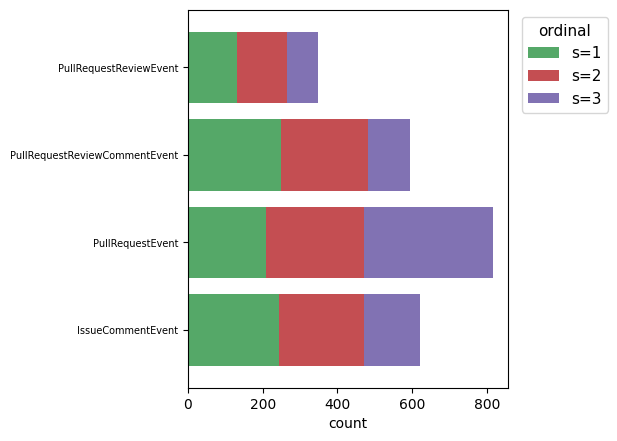

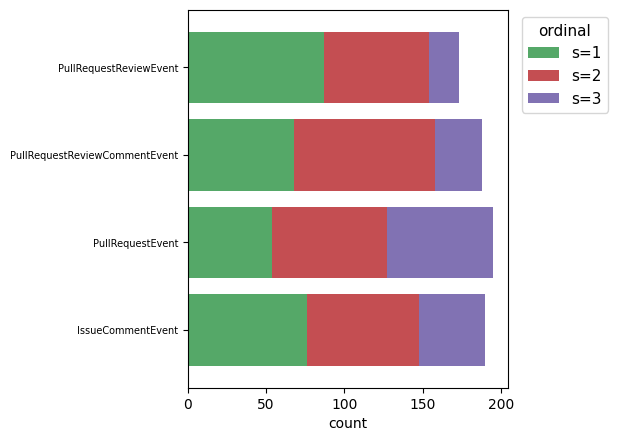

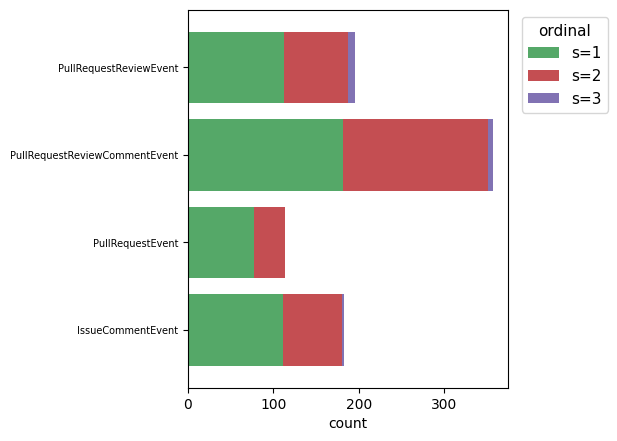

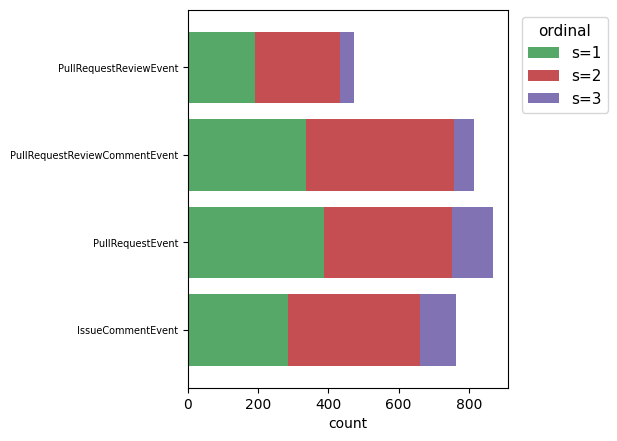

In [33]:
display(Markdown("**Same grouping, stacks omit s=0** (only s=1,2,3)"))
model_label = f" (model: {SELECTED_MODELS[0]})" if len(SELECTED_MODELS) == 1 else f" (models: {', '.join(SELECTED_MODELS)})"
plot_score_summaries_by_category(
    df_plot,
    category_col="event_type",
    title=f"Event-type-level judge scores{model_label}",
    include_s0=False,
    one_figure_per_panel=True,
    show_event_type_label_table=False,
)

## All-Zero Score Analysis

Rows where FUN=NSI=INSI=ISI=0 indicate the judge assigned no signal on any dimension. Show count and samples.

In [34]:
df_full = df_filtered.copy()
az = all_zero_scores_mask(df_full)
n_az = int(az.sum())

display(Markdown(
    f"#### All-zero scores (FUN=NSI=INSI=ISI=0)\n\n"
    f"**{n_az}** of **{len(df_full)}** loaded judge rows ({100*n_az/len(df_full):.1f}%)"
))

if n_az > 0:
    display(Markdown("#### Sample `cleaned_text` (truncated; scroll)"))
    display_all_zero_score_comment_samples(df_full, limit=500)

#### All-zero scores (FUN=NSI=INSI=ISI=0)

**1783** of **5734** loaded judge rows (31.1%)

#### Sample `cleaned_text` (truncated; scroll)